<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/DeepLearning2026_Lab5_CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning 2026 – Lab 5
## Introduction to Convolutional Neural Networks (CNNs)
### Image Classification on CIFAR-10 · Step-by-Step Tutorial

**Goal:** Understand the fundamental building blocks of **Convolutional Neural Networks (CNNs)** for computer vision: convolution (`Conv2D`), spatial subsampling (`MaxPooling2D`), flattening (`Flatten`), and dense classification layers (`Dense`).

We train a CNN on the **CIFAR-10 dataset** (10 object categories, 32×32 RGB color images) and inspect each layer's role, tensor shapes, and parameter counts.

### Practice Quiz / Attendance

[Microsoft Forms Quiz Link](https://forms.office.com/Pages/ResponsePage.aspx?id=1AIHVwcBOUqp1XR_i5eukZc5LZUgilVGoA2BjU2-8UhUMU5XV1hZRzE3OThNRzMxS1pJNFkxUTU1US4u)

### 1. Import Libraries

We import TensorFlow, Keras layers and models, as well as Matplotlib for plotting images and learning curves.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 2. Download and Preprocess CIFAR-10

The **CIFAR-10** dataset consists of 60,000 32x32 color images across 10 mutually exclusive classes (6,000 images per class).
- **50,000** training images
- **10,000** test images

Pixel values range from 0 to 255 (unsigned 8-bit integers). We normalize them to the `[0.0, 1.0]` floating-point range by dividing by `255.0`.

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

print(f"Training images shape: {train_images.shape}")
print(f"Test images shape:     {test_images.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2241s 13us/step
Training images shape: (50000, 32, 32, 3)
Test images shape:     (10000, 32, 32, 3)


### 3. Verify and Visualize the Data

Let us plot the first 25 images from the training set alongside their corresponding category names.

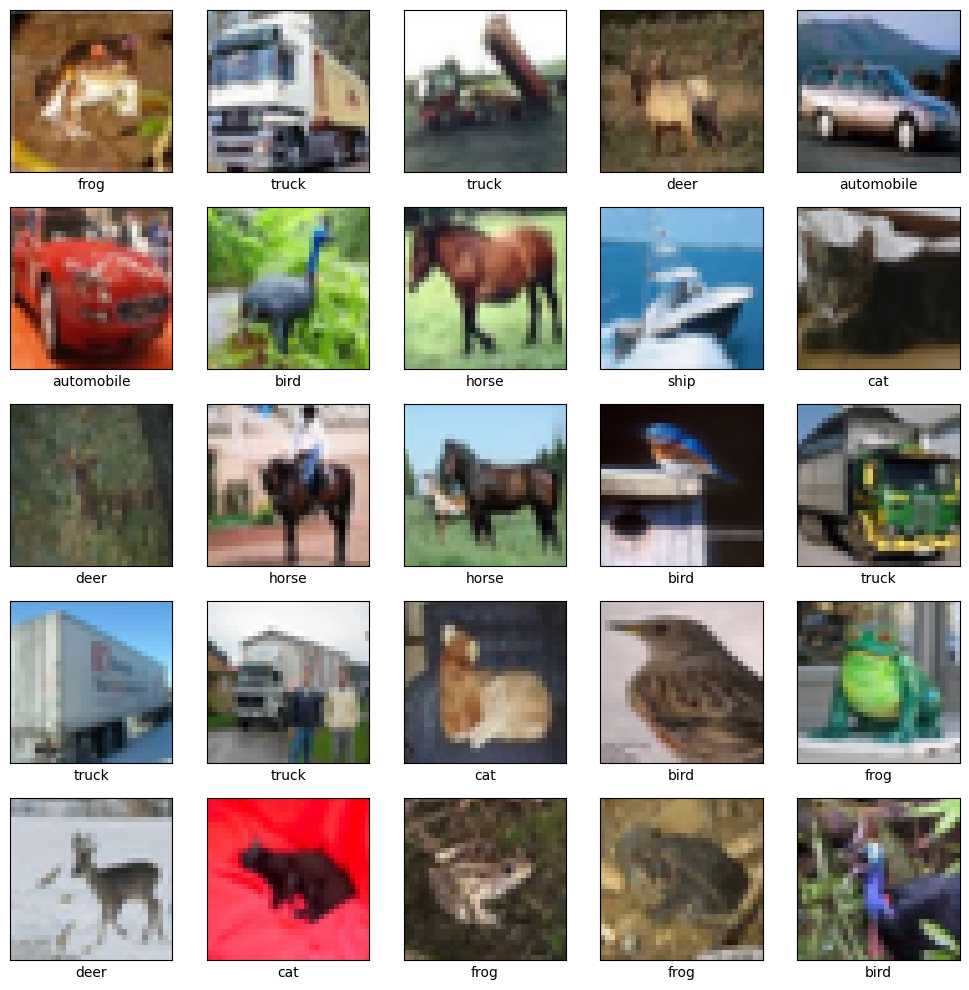

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.tight_layout()
plt.show()

### 4. Build the Convolutional Neural Network

Instead of fragmenting the network creation across separate cells with deprecated arguments, we define the complete architecture clearly in a single, transparent Keras `Sequential` pipeline using modern syntax (`layers.Input`).

#### Architectural Anatomy:
1. **Input Layer:** `Input(shape=(32, 32, 3))` sets the expected image dimensions (height, width, RGB color channels).
2. **Convolutional Base (Feature Extractor):**
   - `Conv2D(32, (3, 3), activation='relu')`: 32 learnable 3×3 filters. Output: `(30, 30, 32)`.
   - `MaxPooling2D((2, 2))`: 2×2 spatial downsampling. Output: `(15, 15, 32)`.
   - `Conv2D(64, (3, 3), activation='relu')`: 64 learnable 3×3 filters. Output: `(13, 13, 64)`.
   - `MaxPooling2D((2, 2))`: 2×2 spatial downsampling. Output: `(6, 6, 64)`.
   - `Conv2D(64, (3, 3), activation='relu')`: 64 learnable 3×3 filters. Output: `(4, 4, 64)`.
3. **Dense Classification Head:**
   - `Flatten()`: Unrolls the 3D feature tensor of shape `(4, 4, 64)` into a 1D vector of $4 \times 4 \times 64 = 1024$ features.
   - `Dense(64, activation='relu')`: Fully connected projection layer with 64 units.
   - `Dense(10)`: Output layer with 10 linear logits corresponding to the 10 object classes.

In [4]:
# Define the full CNN model explicitly
model = models.Sequential([
    # Input layer
    layers.Input(shape=(32, 32, 3)),

    # Convolutional Base
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Dense Classifier Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # 10 output logits (one for each CIFAR-10 class)
])

# Print model architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Compile and Train the Model

- **Optimizer:** `adam`
- **Loss Function:** `SparseCategoricalCrossentropy(from_logits=True)` (since our labels are integer class indices 0–9 and the output layer outputs raw logits)
- **Metric:** `accuracy`
- **Epochs:** 10 passes over the training set

In [5]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4279 - loss: 1.5684 - val_accuracy: 0.5491 - val_loss: 1.2701
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5708 - loss: 1.2079 - val_accuracy: 0.6049 - val_loss: 1.1023
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6254 - loss: 1.0664 - val_accuracy: 0.6473 - val_loss: 1.0084
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6645 - loss: 0.9613 - val_accuracy: 0.6600 - val_loss: 0.9851
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6932 - loss: 0.8786 - val_accuracy: 0.6777 - val_loss: 0.9232
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7144 - loss: 0.8214 - val_accuracy: 0.6605 - val_loss: 0.9854
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7298 - loss: 0.7730 - val_accuracy: 0.6716 - val_loss: 0.9630
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7458 - loss: 0.7282 - val_accuracy: 

### 6. Model Evaluation and Learning Curves

We visualize both accuracy and loss curves over the 10 epochs, comparing training and validation performance.

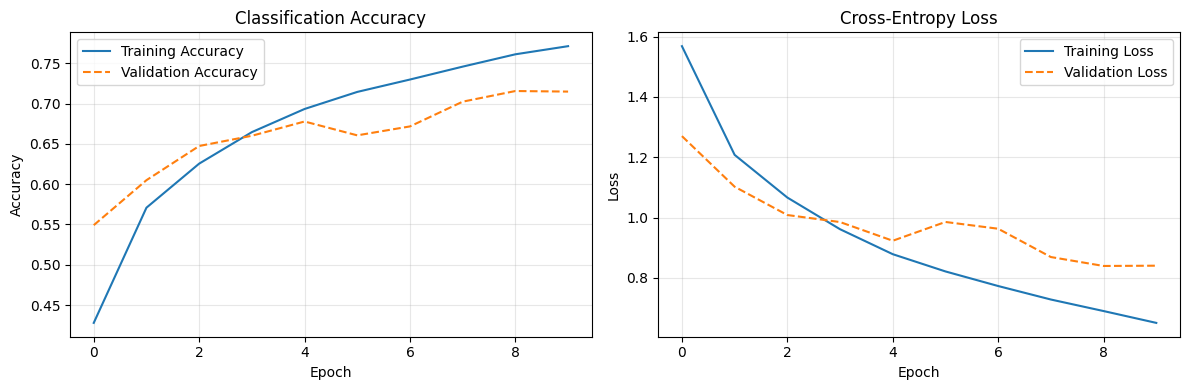

313/313 - 2s - 7ms/step - accuracy: 0.7148 - loss: 0.8404

Test Accuracy: 71.48%
Test Loss:     0.8404


In [6]:
# Plot training & validation metrics
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

### 7. Summary & Key Takeaways

- **Convolutional layers (`Conv2D`):** Preserve 2D spatial relationships and extract local visual patterns (edges, textures, object parts) through shared weights.
- **Pooling layers (`MaxPooling2D`):** Reduce spatial dimensions, lowering compute requirements while providing translation invariance.
- **Dense classifier (`Flatten` + `Dense`):** Combines the extracted visual features to produce final class logits.
- Even this small, unregularized CNN achieves over **70% test accuracy** on CIFAR-10 in just 10 epochs.